# 05 — Data Augmentation and Class-Imbalance Analysis

**Project:** Smart Waste Classification System  
**Dataset:** TrashNet  
**Framework:** PyTorch  
**Author:** Syed Soban Mudassar

---

## Purpose

This notebook validates and explains the training-only augmentation pipeline and the class-imbalance strategy used in the Smart Waste Classification project.

The reusable implementation is stored in:

- `src/augmentation.py`
- `src/data_processing.py`
- `src/class_imbalance.py`

The notebook does not redefine the production logic. Instead, it imports, tests, visualizes, and explains the reusable source-code modules.

---

## Why this stage matters

A model trained on a small image dataset may memorize training examples instead of learning general visual patterns. Data augmentation introduces realistic variability during training and helps improve generalization.

TrashNet is also class-imbalanced. Some categories contain substantially fewer images than others. Weighted cross-entropy will therefore be used so that errors on minority classes contribute more strongly to the training loss.

Validation and test images remain deterministic and do not influence the calculation of class weights.


In [1]:
from __future__ import annotations

import random
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from torchvision import transforms
from torchvision.datasets import ImageFolder

print(f"Python executable: {sys.executable}")
print(f"PyTorch version: {torch.__version__}")

Python executable: c:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\.venv\Scripts\python.exe
PyTorch version: 2.13.0+cpu


## locating project root

In [2]:
def find_project_root(start_path: Path) -> Path:
    """Find the project root by searching for known project files."""

    current_path = start_path.resolve()

    for candidate in [current_path, *current_path.parents]:
        if (
            (candidate / "src").is_dir()
            and (candidate / "data").is_dir()
            and (candidate / "requirements.txt").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root. "
        "Run this notebook from inside the project directory."
    )


PROJECT_ROOT = find_project_root(Path.cwd())

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification


## Importing project modules

In [3]:
from src.augmentation import (
    COLOR_JITTER_BRIGHTNESS,
    COLOR_JITTER_CONTRAST,
    COLOR_JITTER_HUE,
    COLOR_JITTER_SATURATION,
    HORIZONTAL_FLIP_PROBABILITY,
    ROTATION_DEGREES,
    get_training_transform,
)
from src.class_imbalance import (
    calculate_balanced_class_weights,
    get_imagefolder_class_counts,
)
from src.data_processing import (
    DEFAULT_IMAGE_SIZE,
    IMAGENET_MEAN,
    IMAGENET_STD,
    get_evaluation_transform,
)

print("Reusable project modules imported successfully.")

Reusable project modules imported successfully.


## Reproducibility

In [4]:
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print(f"Random seed: {RANDOM_SEED}")

Random seed: 42


## Paths and Configuration

In [5]:
DATA_DIRECTORY = PROJECT_ROOT / "data"
PROCESSED_DIRECTORY = DATA_DIRECTORY / "processed"

TRAIN_DIRECTORY = PROCESSED_DIRECTORY / "train"
VALIDATION_DIRECTORY = PROCESSED_DIRECTORY / "validation"
TEST_DIRECTORY = PROCESSED_DIRECTORY / "test"

EXPECTED_CLASSES = {
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic",
    "trash",
}

for directory in [
    TRAIN_DIRECTORY,
    VALIDATION_DIRECTORY,
    TEST_DIRECTORY,
]:
    assert directory.exists(), f"Missing directory: {directory}"
    assert directory.is_dir(), f"Expected a directory: {directory}"

print(f"Training directory:   {TRAIN_DIRECTORY}")
print(f"Validation directory: {VALIDATION_DIRECTORY}")
print(f"Test directory:       {TEST_DIRECTORY}")
print(f"Image size:           {DEFAULT_IMAGE_SIZE}")

Training directory:   C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\processed\train
Validation directory: C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\processed\validation
Test directory:       C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\processed\test
Image size:           (224, 224)


## Creating datasets

In [6]:
training_transform = get_training_transform()
evaluation_transform = get_evaluation_transform()

training_dataset = ImageFolder(
    root=TRAIN_DIRECTORY,
    transform=training_transform,
)

evaluation_training_dataset = ImageFolder(
    root=TRAIN_DIRECTORY,
    transform=evaluation_transform,
)

validation_dataset = ImageFolder(
    root=VALIDATION_DIRECTORY,
    transform=evaluation_transform,
)

test_dataset = ImageFolder(
    root=TEST_DIRECTORY,
    transform=evaluation_transform,
)

print(f"Training samples:   {len(training_dataset):,}")
print(f"Validation samples: {len(validation_dataset):,}")
print(f"Test samples:       {len(test_dataset):,}")
print(f"Classes:            {training_dataset.classes}")
print(f"Class mapping:      {training_dataset.class_to_idx}")


Training samples:   1,762
Validation samples: 378
Test samples:       381
Classes:            ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Class mapping:      {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


## Verifying class consistency

In [7]:
dataset_classes = set(training_dataset.classes)

assert dataset_classes == EXPECTED_CLASSES
assert training_dataset.class_to_idx == validation_dataset.class_to_idx
assert training_dataset.class_to_idx == test_dataset.class_to_idx

print("Class names and class-index mappings are consistent across all splits.")

Class names and class-index mappings are consistent across all splits.


## Selecting representative images

In [8]:
def select_one_image_per_class(
    dataset: ImageFolder,
) -> list[tuple[Path, str]]:
    """Select the first available image from every dataset class."""

    selected_images: list[tuple[Path, str]] = []

    for class_name in dataset.classes:
        class_index = dataset.class_to_idx[class_name]

        matching_sample = next(
            (
                Path(image_path),
                class_name,
            )
            for image_path, target in dataset.samples
            if target == class_index
        )

        selected_images.append(matching_sample)

    return selected_images


representative_images = select_one_image_per_class(
    evaluation_training_dataset
)

representative_images

[(WindowsPath('C:/Users/Mudassar Iqbal Shah/Documents/Internship/smart-waste-classification/data/processed/train/cardboard/cardboard1.jpg'),
  'cardboard'),
 (WindowsPath('C:/Users/Mudassar Iqbal Shah/Documents/Internship/smart-waste-classification/data/processed/train/glass/glass100.jpg'),
  'glass'),
 (WindowsPath('C:/Users/Mudassar Iqbal Shah/Documents/Internship/smart-waste-classification/data/processed/train/metal/metal1.jpg'),
  'metal'),
 (WindowsPath('C:/Users/Mudassar Iqbal Shah/Documents/Internship/smart-waste-classification/data/processed/train/paper/paper1.jpg'),
  'paper'),
 (WindowsPath('C:/Users/Mudassar Iqbal Shah/Documents/Internship/smart-waste-classification/data/processed/train/plastic/plastic10.jpg'),
  'plastic'),
 (WindowsPath('C:/Users/Mudassar Iqbal Shah/Documents/Internship/smart-waste-classification/data/processed/train/trash/trash1.jpg'),
  'trash')]

## Displaying original images

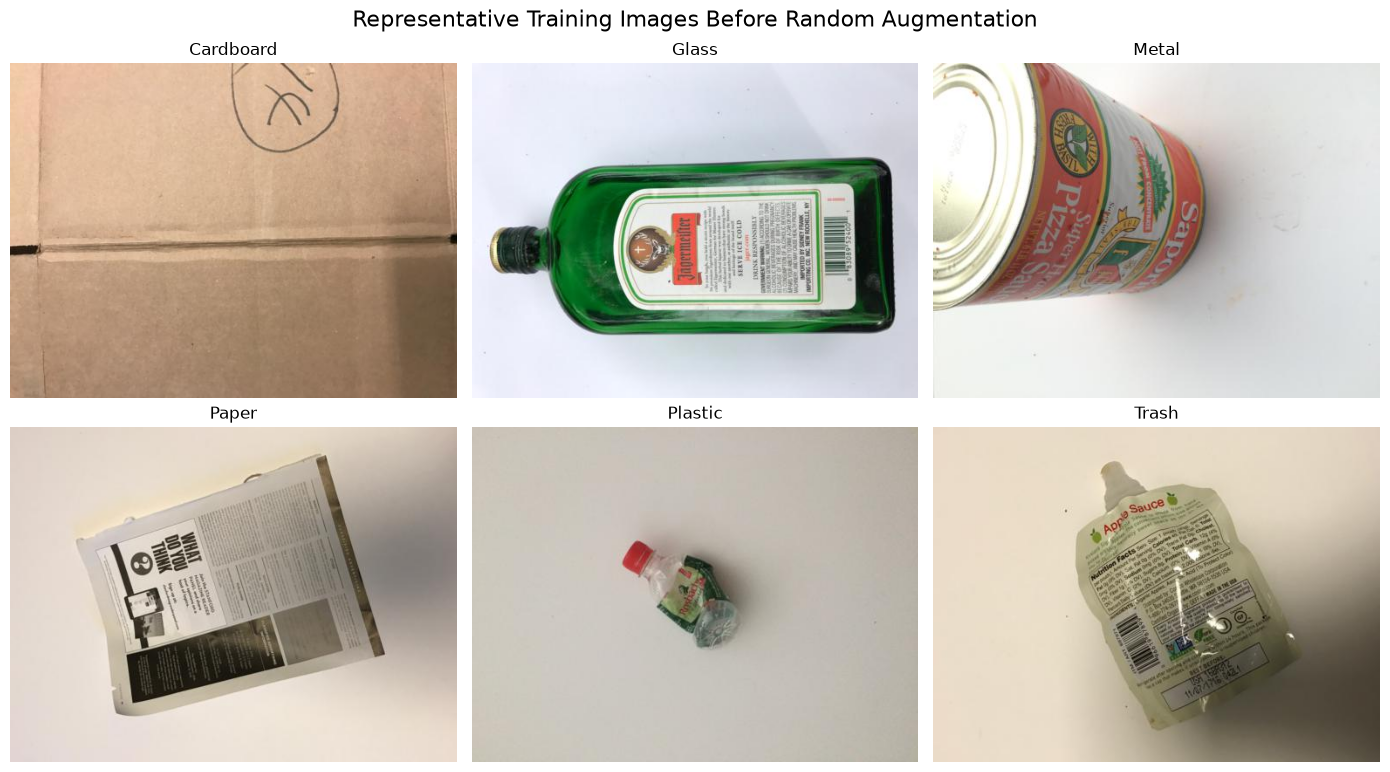

In [9]:
figure, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(14, 8),
)

for axis, (image_path, class_name) in zip(
    axes.flatten(),
    representative_images,
):
    with Image.open(image_path) as image:
        axis.imshow(image.convert("RGB"))

    axis.set_title(class_name.title())
    axis.axis("off")

figure.suptitle(
    "Representative Training Images Before Random Augmentation",
    fontsize=16,
)
figure.tight_layout()
plt.show()

## Unnormalize helper

In [10]:
def denormalize_tensor(
    tensor: torch.Tensor,
) -> torch.Tensor:
    """Reverse ImageNet normalization for visualization."""

    mean = torch.tensor(
        IMAGENET_MEAN,
        dtype=tensor.dtype,
    ).view(3, 1, 1)

    standard_deviation = torch.tensor(
        IMAGENET_STD,
        dtype=tensor.dtype,
    ).view(3, 1, 1)

    denormalized = tensor.cpu() * standard_deviation + mean

    return denormalized.clamp(0.0, 1.0)


def tensor_to_display_array(
    tensor: torch.Tensor,
) -> np.ndarray:
    """Convert a normalized CHW tensor into a displayable HWC array."""

    denormalized = denormalize_tensor(tensor)

    return denormalized.permute(1, 2, 0).numpy()

## Repeated augmentations

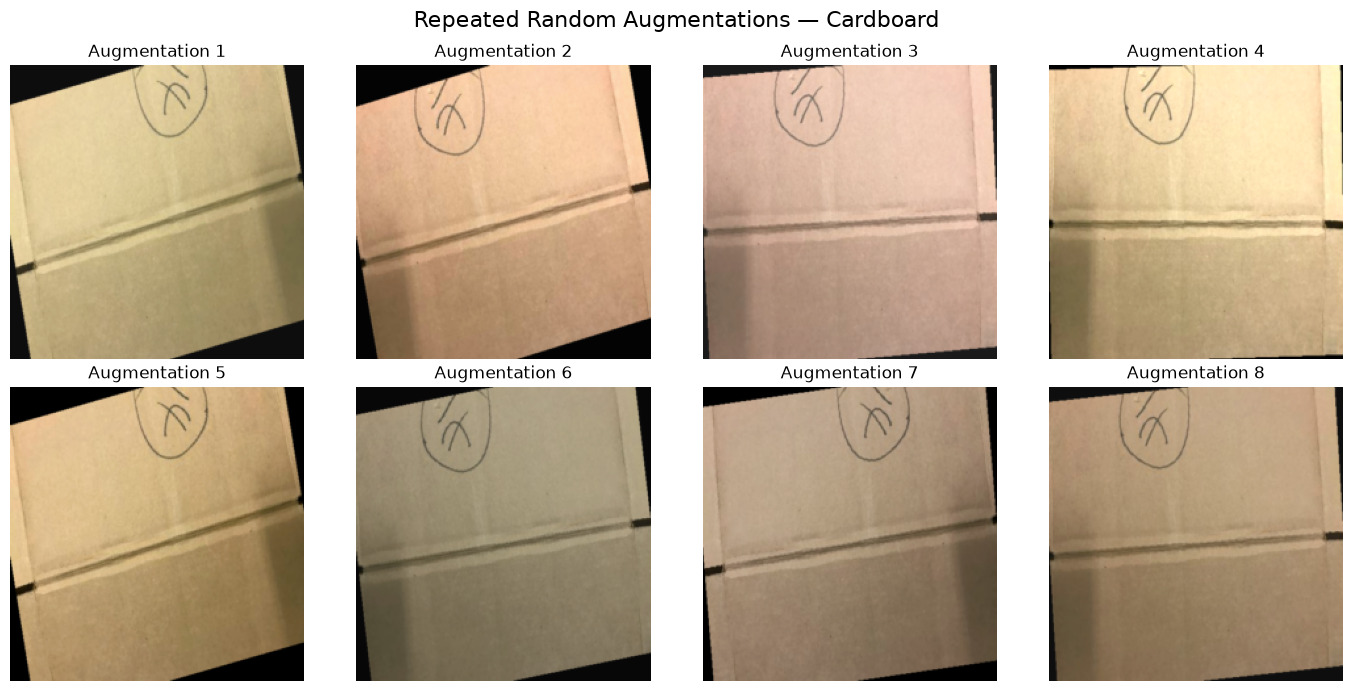

In [11]:
sample_image_path, sample_class_name = representative_images[0]

with Image.open(sample_image_path) as source_image:
    source_image = source_image.convert("RGB")

    augmented_tensors = [
        training_transform(source_image)
        for _ in range(8)
    ]

figure, axes = plt.subplots(
    nrows=2,
    ncols=4,
    figsize=(14, 7),
)

for augmentation_index, (axis, tensor) in enumerate(
    zip(axes.flatten(), augmented_tensors),
    start=1,
):
    axis.imshow(tensor_to_display_array(tensor))
    axis.set_title(f"Augmentation {augmentation_index}")
    axis.axis("off")

figure.suptitle(
    f"Repeated Random Augmentations — {sample_class_name.title()}",
    fontsize=16,
)
figure.tight_layout()
plt.show()

### Interpretation

Each panel comes from the same source image, but the visible result changes because the training pipeline is stochastic.

The transformations remain intentionally moderate:

- rotation does not completely invert the object,
- color adjustment does not destroy the original material appearance,
- horizontal flipping preserves the semantic class,
- the final image size remains consistent.

This creates useful variation without deliberately changing the label.

## Examine transformations independently

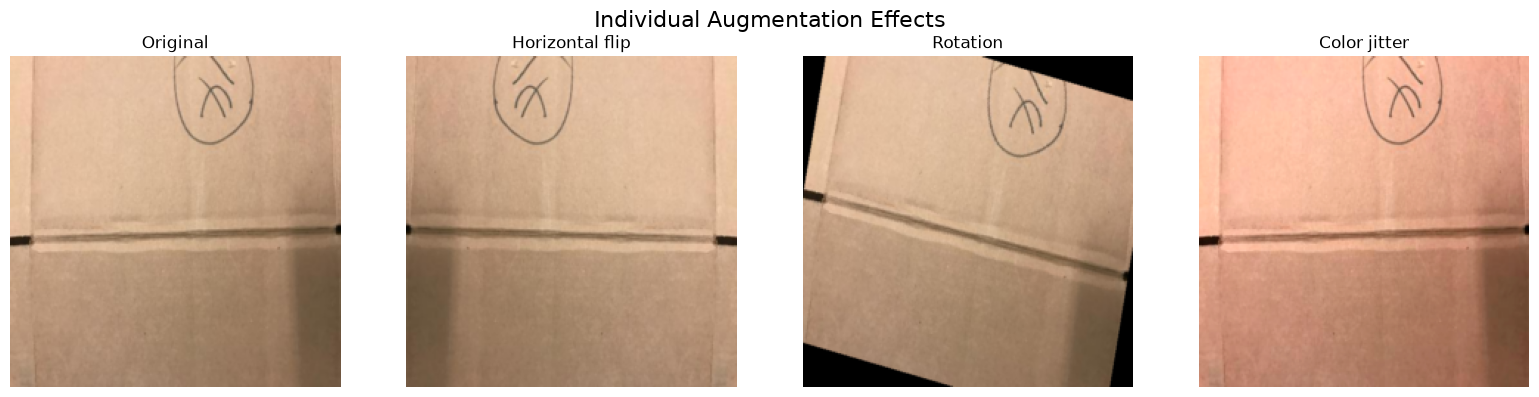

In [12]:
individual_transforms = {
    "Original": transforms.Compose(
        [
            transforms.Resize(
                DEFAULT_IMAGE_SIZE,
                antialias=True,
            ),
            transforms.ToTensor(),
        ]
    ),
    "Horizontal flip": transforms.Compose(
        [
            transforms.RandomHorizontalFlip(p=1.0),
            transforms.Resize(
                DEFAULT_IMAGE_SIZE,
                antialias=True,
            ),
            transforms.ToTensor(),
        ]
    ),
    "Rotation": transforms.Compose(
        [
            transforms.RandomRotation(
                degrees=ROTATION_DEGREES,
            ),
            transforms.Resize(
                DEFAULT_IMAGE_SIZE,
                antialias=True,
            ),
            transforms.ToTensor(),
        ]
    ),
    "Color jitter": transforms.Compose(
        [
            transforms.ColorJitter(
                brightness=COLOR_JITTER_BRIGHTNESS,
                contrast=COLOR_JITTER_CONTRAST,
                saturation=COLOR_JITTER_SATURATION,
                hue=COLOR_JITTER_HUE,
            ),
            transforms.Resize(
                DEFAULT_IMAGE_SIZE,
                antialias=True,
            ),
            transforms.ToTensor(),
        ]
    ),
}

with Image.open(sample_image_path) as image:
    source_image = image.convert("RGB")

    transformed_examples = {
        transformation_name: transformation(source_image)
        for transformation_name, transformation
        in individual_transforms.items()
    }

figure, axes = plt.subplots(
    nrows=1,
    ncols=len(transformed_examples),
    figsize=(16, 4),
)

for axis, (name, tensor) in zip(
    axes,
    transformed_examples.items(),
):
    axis.imshow(tensor.permute(1, 2, 0).numpy())
    axis.set_title(name)
    axis.axis("off")

figure.suptitle(
    "Individual Augmentation Effects",
    fontsize=16,
)
figure.tight_layout()
plt.show()

### Interpretation of individual transformations

**Horizontal flipping**

This reduces dependence on the direction in which an object faces. It is appropriate because waste categories generally do not change under left-right reflection.

**Rotation**

Small rotation improves robustness to camera angle and object placement. The rotation range is restricted to ±15 degrees to avoid creating highly unrealistic examples.

**Color jitter**

Brightness, contrast, saturation, and hue variation approximate differences caused by lighting, cameras, and environments. Excessive color changes could distort material cues, so conservative values are used.

**Resize**

All samples are resized to 224 × 224 pixels so they can be grouped into batches and used by the selected CNN architectures.

## Tensor validation

In [13]:
sample_tensor, sample_target = training_dataset[0]

assert isinstance(sample_tensor, torch.Tensor)
assert sample_tensor.shape == (
    3,
    DEFAULT_IMAGE_SIZE[0],
    DEFAULT_IMAGE_SIZE[1],
)
assert sample_tensor.dtype == torch.float32
assert 0 <= sample_target < len(training_dataset.classes)

print(f"Tensor shape: {sample_tensor.shape}")
print(f"Tensor dtype: {sample_tensor.dtype}")
print(f"Target index: {sample_target}")
print(
    "Target class:",
    training_dataset.classes[sample_target],
)

Tensor shape: torch.Size([3, 224, 224])
Tensor dtype: torch.float32
Target index: 0
Target class: cardboard


## Stochasticity test

In [14]:
with Image.open(sample_image_path) as image:
    source_image = image.convert("RGB")

    first_augmented_tensor = training_transform(source_image)
    second_augmented_tensor = training_transform(source_image)

training_outputs_equal = torch.equal(
    first_augmented_tensor,
    second_augmented_tensor,
)

print(
    "Are two training transformations exactly equal?",
    training_outputs_equal,
)

Are two training transformations exactly equal? False


## Deterministic evaluation test

In [16]:
with Image.open(sample_image_path) as image:
    source_image = image.convert("RGB")

    first_evaluation_tensor = evaluation_transform(source_image)
    second_evaluation_tensor = evaluation_transform(source_image)

evaluation_outputs_equal = torch.equal(
    first_evaluation_tensor,
    second_evaluation_tensor,
)

assert evaluation_outputs_equal

print(
    "Are two evaluation transformations exactly equal?",
    evaluation_outputs_equal,
)

Are two evaluation transformations exactly equal? True


##  Training class-distribution analysis

Class weights must be based only on the processed training split.

Using validation or test labels when calculating weights would allow evaluation data to influence the training procedure. That would weaken the independence of the final performance estimate.

## Counts and Weights

In [17]:
training_class_counts = get_imagefolder_class_counts(
    evaluation_training_dataset
)

training_class_weights = calculate_balanced_class_weights(
    training_class_counts
)

class_imbalance_records = []

for class_index, class_name in enumerate(
    evaluation_training_dataset.classes
):
    class_imbalance_records.append(
        {
            "class_index": class_index,
            "class_name": class_name,
            "training_samples": training_class_counts[class_index],
            "class_weight": float(
                training_class_weights[class_index]
            ),
        }
    )

class_imbalance_dataframe = pd.DataFrame(
    class_imbalance_records
)

class_imbalance_dataframe

,class_index,class_name,training_samples,class_weight
0,0,cardboard,282,0.823770
1,1,glass,348,0.667538
2,2,metal,286,0.812249
3,3,paper,415,0.559767
4,4,plastic,336,0.691379
5,5,trash,95,2.445297


## Verify weights

In [18]:
assert len(training_class_counts) == 6
assert training_class_weights.shape == (6,)
assert torch.isclose(
    training_class_weights.mean(),
    torch.tensor(1.0),
)

minority_row = class_imbalance_dataframe.loc[
    class_imbalance_dataframe["training_samples"].idxmin()
]

majority_row = class_imbalance_dataframe.loc[
    class_imbalance_dataframe["training_samples"].idxmax()
]

print("Minority class:")
print(minority_row)

print("\nMajority class:")
print(majority_row)

Minority class:
class_index                5
class_name             trash
training_samples          95
class_weight        2.445297
Name: 5, dtype: object

Majority class:
class_index                3
class_name             paper
training_samples         415
class_weight        0.559767
Name: 3, dtype: object


## Plot counts

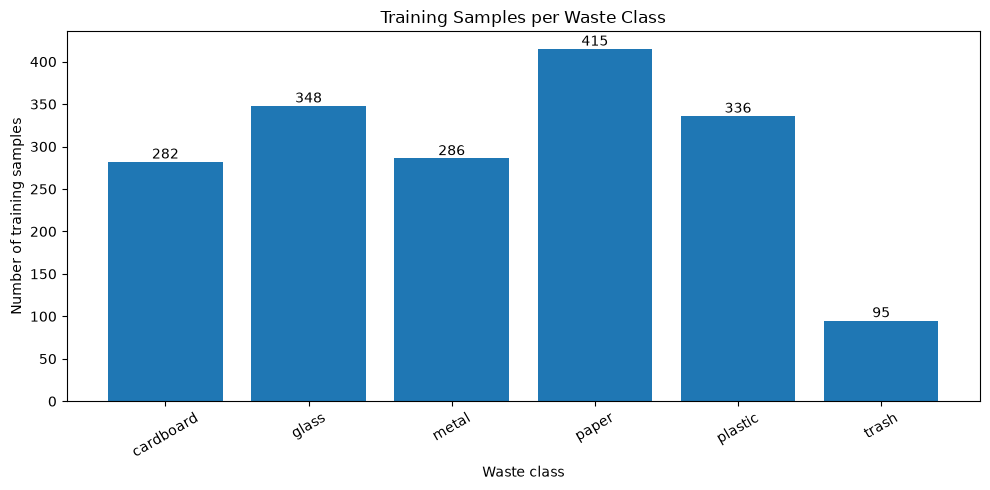

In [19]:
figure, axis = plt.subplots(figsize=(10, 5))

axis.bar(
    class_imbalance_dataframe["class_name"],
    class_imbalance_dataframe["training_samples"],
)

axis.set_title("Training Samples per Waste Class")
axis.set_xlabel("Waste class")
axis.set_ylabel("Number of training samples")
axis.tick_params(
    axis="x",
    rotation=30,
)

for position, sample_count in enumerate(
    class_imbalance_dataframe["training_samples"]
):
    axis.text(
        position,
        sample_count,
        str(sample_count),
        ha="center",
        va="bottom",
    )

figure.tight_layout()
plt.show()

### Class-count interpretation

The training set is not evenly distributed.

The paper class contains the largest number of images, while trash contains substantially fewer images. Without an imbalance strategy, the loss function would receive more frequent updates from majority-class examples simply because those examples appear more often.

This may encourage the model to favor common classes and underperform on trash, even when overall accuracy looks acceptable.

## Plot weights

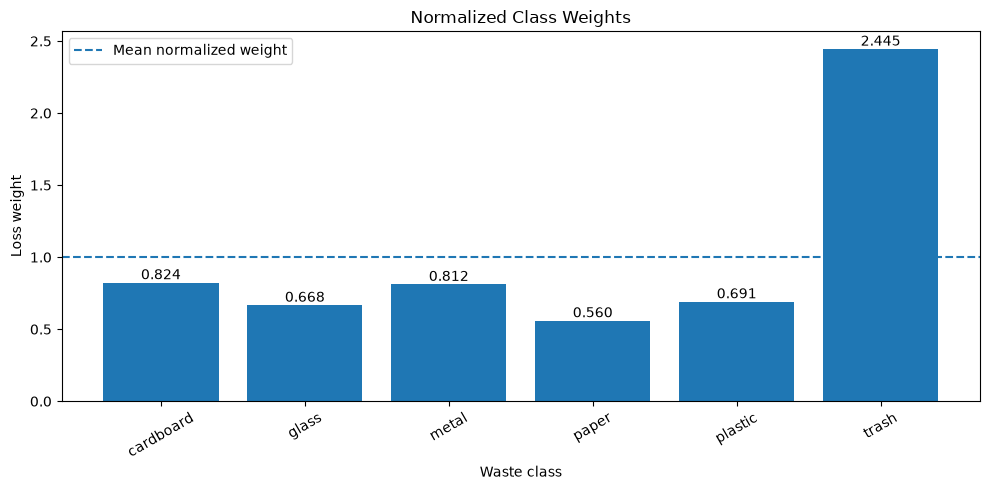

In [20]:
figure, axis = plt.subplots(figsize=(10, 5))

axis.bar(
    class_imbalance_dataframe["class_name"],
    class_imbalance_dataframe["class_weight"],
)

axis.axhline(
    y=1.0,
    linestyle="--",
    label="Mean normalized weight",
)

axis.set_title("Normalized Class Weights")
axis.set_xlabel("Waste class")
axis.set_ylabel("Loss weight")
axis.tick_params(
    axis="x",
    rotation=30,
)
axis.legend()

for position, class_weight in enumerate(
    class_imbalance_dataframe["class_weight"]
):
    axis.text(
        position,
        class_weight,
        f"{class_weight:.3f}",
        ha="center",
        va="bottom",
    )

figure.tight_layout()
plt.show()

### Class-weight interpretation

Class weights move in the opposite direction to class frequency:

- frequently represented classes receive weights below 1,
- underrepresented classes receive larger weights,
- trash receives the largest weight,
- paper receives the smallest weight.

During training, these weights will be passed to `torch.nn.CrossEntropyLoss`.

A misclassified trash image will therefore have a larger influence on the loss than a misclassified paper image. This does not guarantee equal class performance, but it gives the optimizer a stronger reason to learn minority-class patterns.

## Demonstrating weighted loss

In [21]:
example_logits = torch.tensor(
    [
        [2.0, 0.5, 0.4, 0.3, 0.2, 0.1],
        [0.4, 0.3, 0.2, 2.0, 0.1, 0.0],
    ],
    dtype=torch.float32,
)

example_targets = torch.tensor(
    [
        training_dataset.class_to_idx["trash"],
        training_dataset.class_to_idx["paper"],
    ],
    dtype=torch.long,
)

unweighted_criterion = torch.nn.CrossEntropyLoss(
    reduction="none",
)

weighted_criterion = torch.nn.CrossEntropyLoss(
    weight=training_class_weights,
    reduction="none",
)

unweighted_losses = unweighted_criterion(
    example_logits,
    example_targets,
)

weighted_losses = weighted_criterion(
    example_logits,
    example_targets,
)

loss_comparison = pd.DataFrame(
    {
        "true_class": ["trash", "paper"],
        "unweighted_loss": unweighted_losses.numpy(),
        "weighted_loss": weighted_losses.numpy(),
    }
)

loss_comparison

,true_class,unweighted_loss,weighted_loss
0,trash,2.553667,6.244474
1,paper,0.606926,0.339737


## Leakage safeguard

In [22]:
training_only_counts = Counter(
    evaluation_training_dataset.targets
)

validation_counts = Counter(
    validation_dataset.targets
)

test_counts = Counter(
    test_dataset.targets
)

assert sum(training_only_counts.values()) == len(
    evaluation_training_dataset
)

print(
    "Class weights were calculated from:",
    TRAIN_DIRECTORY,
)
print(
    "Validation images excluded from weight calculation:",
    len(validation_dataset),
)
print(
    "Test images excluded from weight calculation:",
    len(test_dataset),
)

Class weights were calculated from: C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\processed\train
Validation images excluded from weight calculation: 378
Test images excluded from weight calculation: 381


##  Client-requirement mapping

This milestone supports the following project requirements:

| Requirement | Implementation |
|---|---|
| Reusable resizing and normalization | `src/data_processing.py` |
| Reusable training augmentation | `src/augmentation.py` |
| Class-imbalance handling | `src/class_imbalance.py` |
| Data-leakage prevention | Training-only augmentation and training-only weight calculation |
| Automated preprocessing tests | `tests/test_data_processing.py` |
| Automated augmentation tests | `tests/test_augmentation.py` |
| Automated imbalance tests | `tests/test_class_imbalance.py` |
| Written analysis | Interpretations throughout this notebook |
| Reproducibility | Fixed random seed and documented configuration |
| Modular source code | Notebook imports source modules rather than redefining them |

##  Conclusion

The project now has a reusable and validated preprocessing pipeline consisting of:

- deterministic resizing and ImageNet normalization,
- training-only horizontal flipping,
- training-only rotation,
- training-only color jitter,
- inverse-frequency class weighting,
- leakage-safe split usage,
- automated tests for critical behavior.

The next milestone is development of a simple CNN from scratch. That model will establish a baseline performance benchmark before the required transfer-learning models are introduced.